## Polynomial Regression

Linear regression fits a straight line — but many real relationships are curved. Polynomial regression handles this **without changing the underlying algorithm at all**: you keep using the same linear regression machinery (cost function, gradient descent), but engineer new features that are powers of your original feature.

### The core idea

Instead of fitting:

$$f_{w,b}(x) = wx + b$$

you create new features $x^2$, $x^3$, etc. from your original $x$, and fit:

$$f_{\mathbf{w},b}(x) = w_1x + w_2x^2 + w_3x^3 + b$$

This is still **linear regression** — it's linear in the *parameters* $w_1, w_2, w_3$, even though the relationship between $x$ and the prediction is now curved. You're not changing the model or the training algorithm; you're changing the **input features**.

### Why this matters practically

- Each new feature ($x$, $x^2$, $x^3$, ...) becomes its own column in your data matrix $X$, exactly like any other feature.
- Because the features now have very different scales ($x$ vs $x^2$ vs $x^3$ grow at wildly different rates), **feature scaling (z-score normalization) becomes essential** here — more so than in plain linear regression — otherwise gradient descent will struggle to converge.
- You choose the polynomial degree (how high to go: $x^2$? $x^3$?) — higher degree fits training data more closely, but risks overfitting (fitting noise, not the underlying pattern), which is a topic covered later.

### Steps

1. Start with your original feature(s) $x$
2. Engineer new columns: $x^2$, $x^3$, etc.
3. Combine into a feature matrix $X = [x, x^2, x^3, ...]$
4. Apply z-score normalization to $X$ (critical here — feature scales are very different)
5. Run the same `compute_cost`, `compute_gradient`, `gradient_descent` you already have — no changes needed to those functions

**`np.random.seed(1)`** — Sets the starting point for NumPy's random number generator. Without this, `np.random.normal(...)` would give different random noise values every time you run the script. Setting a seed makes the "random" numbers reproducible — same seed, same noise, every run.

**`np.arange(0, 20, 1)`** — Generates evenly spaced values: `start=0`, `stop=20` (excluded), `step=1` → `[0, 1, 2, ..., 19]`. Chosen here to get a clean, evenly-spaced range of x-values — 20 points is enough to see a curve shape without being excessive.

**`.reshape(-1, 1)`** — `np.arange(0, 20, 1)` produces a 1D array with shape `(20,)`. `LinearRegression.fit()` requires input `X` to be 2D, shaped `(m, n)` — `m` examples, `n` features — even with only 1 feature. `.reshape(-1, 1)` converts shape `(20,)` → `(20, 1)`. The `-1` tells NumPy "figure out this dimension automatically based on total elements," so it works regardless of how many values `x` contains; the `1` means "1 column" (1 feature).

**`np.random.normal(0, 5, x.shape[0])`** — Generates random noise from a normal distribution: mean `0`, standard deviation `5`, `x.shape[0]` values (one per example, 20 total). Added so the data resembles realistic, imperfect measurements rather than a perfectly smooth curve.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(1)
x = np.arange(0, 20, 1).reshape(-1, 1)
y = 1 + x.flatten()**2 + np.random.normal(0, 5, x.shape[0])

**`LinearRegression()`** (from `sklearn.linear_model`) — Creates an untrained linear regression model object. It holds no learned parameters yet — just an empty model waiting to be fit.

**`.fit(X, y)`** — Trains the model: finds `w` and `b` that minimize $J(\mathbf{w},b)$ for the given `X` and `y`. This is the scikit-learn equivalent of calling your own `gradient_descent` function — except scikit-learn typically solves it directly via linear algebra (normal equation) rather than iterating, so it doesn't need an `alpha` or `num_iters`. After fitting, parameters are stored as `lin_model.coef_` (the `w` values) and `lin_model.intercept_` (the `b` value).

**`.predict(X)`** — Uses the trained model to compute $f_{w,b}(x) = wx + b$ for every row in `X`. Equivalent to manually computing `np.dot(X, w) + b`.

In [5]:
lin_model = LinearRegression()
lin_model.fit(x, y)
y_pred_linear = lin_model.predict(x)

**`np.c_[x, x**2]`** — Stacks arrays together as columns. Combines `x` and `x**2` side-by-side into a single `(m, 2)` matrix — column 0 is the original feature, column 1 is that feature squared. This is the feature engineering step.

**`LinearRegression()` reused** — Note this is the exact same class as Chunk 2. Despite the name, it's still valid here: it's "linear in the parameters," so feeding it `[x, x^2]` as input still counts as linear regression under the hood — the curve comes from the engineered feature, not from the model itself.

In [6]:
X_poly = np.c_[x, x**2]
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

**`plt.figure(figsize=(8, 5))`** — Creates a blank plot canvas, 8 inches wide by 5 inches tall, giving explicit control over plot proportions.

**`plt.scatter(x, y, ...)`** — Plots individual data points (dots) rather than a connected line — appropriate for raw/actual data shown as discrete observations.
- `color='gray'`: dot color
- `label='...'`: text shown in the legend
- `alpha=0.6`: transparency (0=invisible, 1=opaque) — helps visibility when points overlap

**`plt.plot(x, y_pred, ...)`** — Plots a connected line through `(x, y_pred)` — appropriate here since `y_pred` is a continuous fitted function, not discrete data.
- `linewidth=2`: line thickness

**`plt.xlabel(...)` / `plt.ylabel(...)`** — Text labels for the x-axis and y-axis.

**`plt.title(...)`** — Text shown above the plot.

**`plt.legend()`** — Displays a legend box, pulling in the `label=` text from each `scatter`/`plot` call.

**`plt.show()`** — Renders and displays the plot. Not strictly required in a Jupyter notebook (plots often auto-display), but good practice to include explicitly.

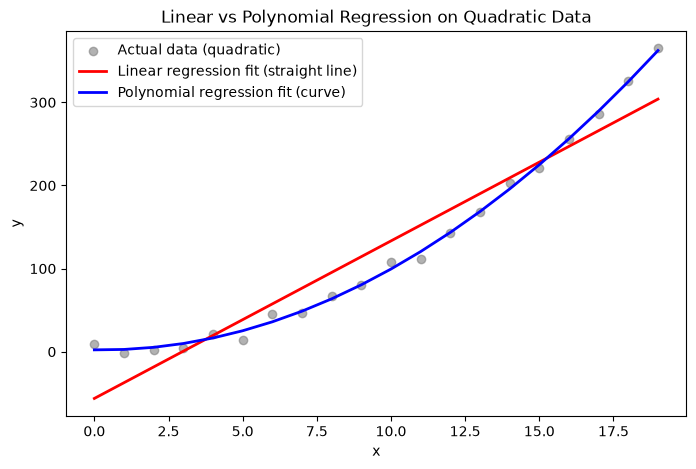

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='gray', label='Actual data (quadratic)', alpha=0.6)
plt.plot(x, y_pred_linear, color='red', label='Linear regression fit (straight line)', linewidth=2)
plt.plot(x, y_pred_poly, color='blue', label='Polynomial regression fit (curve)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear vs Polynomial Regression on Quadratic Data')
plt.legend()
plt.show()